In [2]:
# ============================================
# IMPORTS
# ============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.decomposition import PCA

import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, LeakyReLU, BatchNormalization, Dropout
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.20.0


In [3]:
# ============================================
# LOAD AND EXPLORE DATA
# ============================================
# Download from: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
# Or use your local path
df = pd.read_csv('creditcard.csv')

print("Dataset shape:", df.shape)
print("\nClass distribution:")
print(df['Class'].value_counts())
print(f"\nFraud cases: {df['Class'].sum()} ({df['Class'].mean()*100:.4f}%)")

# Basic statistics
print("\nTransaction amount stats:")
print(df['Amount'].describe())

Dataset shape: (208035, 31)

Class distribution:
Class
0.0    207641
1.0       393
Name: count, dtype: int64

Fraud cases: 393.0 (0.1889%)

Transaction amount stats:
count    208034.000000
mean         89.907117
std         248.009594
min           0.000000
25%           5.990000
50%          23.000000
75%          79.590000
max       19656.530000
Name: Amount, dtype: float64


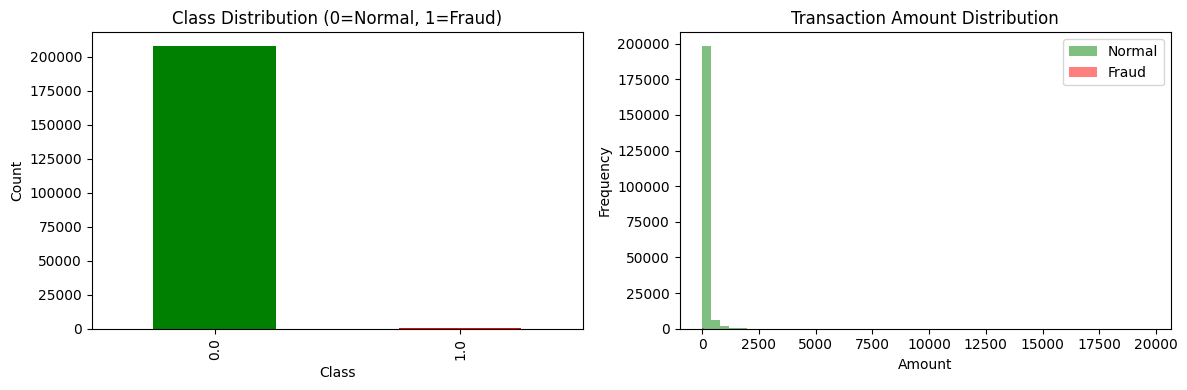

In [4]:
# ============================================
# VISUALIZE CLASS IMBALANCE
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class distribution
df['Class'].value_counts().plot(kind='bar', ax=axes[0], color=['green', 'red'])
axes[0].set_title('Class Distribution (0=Normal, 1=Fraud)')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')

# Amount distribution by class
fraud = df[df['Class'] == 1]['Amount']
normal = df[df['Class'] == 0]['Amount']
axes[1].hist(normal, bins=50, alpha=0.5, label='Normal', color='green')
axes[1].hist(fraud, bins=20, alpha=0.5, label='Fraud', color='red')
axes[1].set_title('Transaction Amount Distribution')
axes[1].set_xlabel('Amount')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

In [5]:
# ============================================
# PREPROCESSING
# ============================================
# Remove 'Time' column as it's not relevant for our demo
# Keep 'Amount' and scale it
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])

# Drop original 'Time' and 'Amount' columns
X = df.drop(['Class', 'Time', 'Amount'], axis=1)
y = df['Class']

print(f"Features shape: {X.shape}")

# IMPORTANT: For GAN anomaly detection, we train discriminator ONLY on NORMAL data
X_normal = X[y == 0]  # Only legitimate transactions for training the discriminator
X_fraud = X[y == 1]

print(f"Normal transactions for training: {X_normal.shape[0]}")
print(f"Fraud transactions (will be used as test anomalies): {X_fraud.shape[0]}")

Features shape: (208035, 29)
Normal transactions for training: 207641
Fraud transactions (will be used as test anomalies): 393


In [6]:
# ============================================
# SPLIT DATA
# ============================================
# Split normal data for training the discriminator
# Use a small validation set from normal data
X_train_norm, X_val_norm = train_test_split(
    X_normal, test_size=0.2, random_state=42, shuffle=True
)

# Keep fraud data completely separate for testing
X_test_fraud = X_fraud

# Also take some normal data for testing
X_test_norm = X_val_norm

print(f"\nTraining normal samples: {X_train_norm.shape[0]}")
print(f"Validation normal samples: {X_val_norm.shape[0]}")
print(f"Test fraud samples: {X_test_fraud.shape[0]}")



Training normal samples: 166112
Validation normal samples: 41529
Test fraud samples: 393


In [7]:
# ============================================
# BUILD GENERATOR MODEL
# ============================================
def build_generator(latent_dim, output_dim):
    """
    Generator creates synthetic fraud transactions from random noise.
    """
    model = Sequential(name="Generator")

    model.add(Dense(128, input_dim=latent_dim))
    model.add(LeakyReLU(alpha=0.2))
    model.add(BatchNormalization(momentum=0.8))

    model.add(Dense(256))
    model.add(LeakyReLU(alpha=0.2))
    model.add(BatchNormalization(momentum=0.8))

    model.add(Dense(512))
    model.add(LeakyReLU(alpha=0.2))
    model.add(BatchNormalization(momentum=0.8))

    model.add(Dense(output_dim, activation='tanh'))

    return model


In [8]:
# ============================================
# BUILD DISCRIMINATOR MODEL (Anomaly Detector)
# ============================================
def build_discriminator(input_dim):
    """
    Discriminator distinguishes real (normal) from fake (anomaly) transactions.
    After training, this becomes our anomaly detector.
    """
    model = Sequential(name="Discriminator")

    model.add(Dense(512, input_dim=input_dim))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dropout(0.3))

    model.add(Dense(256))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dropout(0.3))

    model.add(Dense(128))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dropout(0.3))

    model.add(Dense(1, activation='sigmoid'))

    return model

In [9]:
# ============================================
# BUILD COMPLETE GAN
# ============================================
def build_gan(generator, discriminator):
    """
    Combined GAN model for training the generator.
    """
    discriminator.trainable = False

    gan_input = Input(shape=(latent_dim,))
    generated = generator(gan_input)
    gan_output = discriminator(generated)

    gan = Model(gan_input, gan_output, name="GAN")
    return gan


In [10]:
# ============================================
# GAN TRAINING PARAMETERS
# ============================================
latent_dim = 100
data_dim = X_train_norm.shape[1]

# Build models
generator = build_generator(latent_dim, data_dim)
discriminator = build_discriminator(data_dim)
gan = build_gan(generator, discriminator)

# Compile models
optimizer = Adam(learning_rate=0.0002, beta_1=0.5)

discriminator.compile(
    loss='binary_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

gan.compile(
    loss='binary_crossentropy',
    optimizer=optimizer
)

print("\n=== Generator Summary ===")
generator.summary()

print("\n=== Discriminator Summary ===")
discriminator.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(



=== Generator Summary ===


Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 29)             │        14,877 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 195,997 (765.61 KB)

...

Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 512)            │        15,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 179,713 (702.00 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 179,713 (702.00 KB)

In [11]:
# ============================================
# TRAINING FUNCTION
# ============================================
def train_gan(generator, discriminator, gan, X_train, epochs=200, batch_size=64):
    """
    Train the GAN for anomaly detection.
    Discriminator is trained ONLY on normal data (labeled as REAL).
    """
    history = {'d_loss': [], 'g_loss': [], 'd_acc': []}

    # Prepare training data - all normal transactions are "real" (label=1)
    # We'll never train discriminator on fake data directly
    # Instead, we use the adversarial training

    for epoch in range(epochs):
        d_losses = []
        g_losses = []
        d_accs = []

        # Number of batches
        n_batches = X_train.shape[0] // batch_size

        for batch in range(n_batches):
            # Get batch of real (normal) data
            idx = np.random.randint(0, X_train.shape[0], batch_size)
            real_data = X_train[idx]

            # Labels: 1 = real (normal transaction)
            real_labels = np.ones((batch_size, 1))

            # ----- Train Discriminator -----
            # Train on real data (normal transactions)
            d_loss_real, d_acc_real = discriminator.train_on_batch(real_data, real_labels)

            # Generate fake data from generator
            noise = np.random.normal(0, 1, (batch_size, latent_dim))
            fake_data = generator.predict(noise, verbose=0)

            # Labels: 0 = fake (anomaly)
            fake_labels = np.zeros((batch_size, 1))

            # Train discriminator on fake data
            d_loss_fake, d_acc_fake = discriminator.train_on_batch(fake_data, fake_labels)

            # Average discriminator loss
            d_loss = 0.5 * (d_loss_real + d_loss_fake)
            d_acc = 0.5 * (d_acc_real + d_acc_fake)

            d_losses.append(d_loss)
            d_accs.append(d_acc)

            # ----- Train Generator -----
            # Generator wants discriminator to think fake is real (label=1)
            noise = np.random.normal(0, 1, (batch_size, latent_dim))
            misleading_labels = np.ones((batch_size, 1))

            g_loss = gan.train_on_batch(noise, misleading_labels)
            g_losses.append(g_loss)

        # Store epoch metrics
        avg_d_loss = np.mean(d_losses)
        avg_g_loss = np.mean(g_losses)
        avg_d_acc = np.mean(d_accs)

        history['d_loss'].append(avg_d_loss)
        history['g_loss'].append(avg_g_loss)
        history['d_acc'].append(avg_d_acc)

        # Print progress
        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1}/{epochs} - D Loss: {avg_d_loss:.4f}, G Loss: {avg_g_loss:.4f}, D Acc: {avg_d_acc:.4f}")

    return history


In [ ]:
# ============================================
# TRAIN THE GAN
# ============================================
print("\n" + "="*60)
print("Starting GAN Training for Anomaly Detection")
print("="*60)
print(f"Training on {X_train_norm.shape[0]} normal transactions")
print(f"Latent dimension: {latent_dim}")
print(f"Feature dimension: {data_dim}")

history = train_gan(
    generator, discriminator, gan,
    X_train_norm.values.astype(np.float32),
    epochs=200,
    batch_size=64
)


Starting GAN Training for Anomaly Detection
Training on 166112 normal transactions
Latent dimension: 100
Feature dimension: 29


/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


In [ ]:
# ============================================
# VISUALIZE TRAINING HISTORY
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['d_loss'], label='Discriminator Loss', color='blue')
axes[0].plot(history['g_loss'], label='Generator Loss', color='red')
axes[0].set_title('GAN Training Losses')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['d_acc'], label='Discriminator Accuracy', color='green')
axes[1].set_title('Discriminator Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# ANOMALY DETECTION WITH TRAINED DISCRIMINATOR
# ============================================
def detect_anomalies(discriminator, X_data, threshold=0.5):
    """
    Use trained discriminator to detect anomalies.
    Lower probability = more likely to be an anomaly (fraud).
    """
    predictions = discriminator.predict(X_data, verbose=0)
    anomalies = (predictions < threshold).flatten()
    scores = predictions.flatten()
    return anomalies, scores

# Test on normal transactions
normal_anomalies, normal_scores = detect_anomalies(discriminator, X_test_norm.values.astype(np.float32))

# Test on fraud transactions
fraud_anomalies, fraud_scores = detect_anomalies(discriminator, X_test_fraud.values.astype(np.float32))

# ============================================
# EVALUATION METRICS
# ============================================
# Create true labels and predictions
y_true = np.concatenate([
    np.zeros(len(normal_scores)),  # Normal = 0 (not anomaly)
    np.ones(len(fraud_scores))      # Fraud = 1 (is anomaly)
])
y_scores = np.concatenate([normal_scores, fraud_scores])

# For binary classification (anomaly detection), we invert scores
# Since discriminator outputs HIGH probability for normal, LOW for fraud
# We want anomaly score = 1 - discriminator output
anomaly_scores = 1 - y_scores

# Classification at threshold 0.5
y_pred = (anomaly_scores > 0.5).astype(int)

print("\n" + "="*60)
print("ANOMALY DETECTION RESULTS")
print("="*60)

print(f"\nNormal transactions correctly identified (specificity):")
print(f"  Correctly classified as normal: {(y_pred[y_true==0]==0).sum()} / {len(y_true[y_true==0])}")
print(f"  False positive rate: {(y_pred[y_true==0]==1).sum() / len(y_true[y_true==0]):.4f}")

print(f"\nFraud transactions detected (sensitivity/recall):")
print(f"  Correctly flagged as fraud: {(y_pred[y_true==1]==1).sum()} / {len(y_true[y_true==1])}")
print(f"  Missed fraud: {(y_pred[y_true==1]==0).sum()}")

print(f"\nOverall accuracy: {np.mean(y_pred == y_true):.4f}")

# Classification Report
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_true, y_pred, target_names=['Normal', 'Fraud']))

# ROC-AUC Score
auc_score = roc_auc_score(y_true, anomaly_scores)
print(f"\nROC-AUC Score: {auc_score:.4f}")

# ============================================
# VISUALIZE RESULTS
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Score Distribution
axes[0,0].hist(normal_scores, bins=30, alpha=0.5, label='Normal Transactions', color='green')
axes[0,0].hist(fraud_scores, bins=30, alpha=0.5, label='Fraud Transactions', color='red')
axes[0,0].axvline(x=0.5, color='black', linestyle='--', label='Threshold (0.5)')
axes[0,0].set_title('Discriminator Output Distribution')
axes[0,0].set_xlabel('Probability (Higher = More Normal)')
axes[0,0].set_ylabel('Count')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# 2. Anomaly Score Distribution
axes[0,1].hist(anomaly_scores[y_true==0], bins=30, alpha=0.5, label='Normal', color='green')
axes[0,1].hist(anomaly_scores[y_true==1], bins=30, alpha=0.5, label='Fraud', color='red')
axes[0,1].axvline(x=0.5, color='black', linestyle='--', label='Threshold')
axes[0,1].set_title('Anomaly Score Distribution (1 - Probability)')
axes[0,1].set_xlabel('Anomaly Score (Higher = More Anomalous)')
axes[0,1].set_ylabel('Count')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# 3. ROC Curve
fpr, tpr, thresholds = roc_curve(y_true, anomaly_scores)
axes[1,0].plot(fpr, tpr, color='blue', label=f'GAN (AUC = {auc_score:.4f})')
axes[1,0].plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
axes[1,0].set_title('ROC Curve')
axes[1,0].set_xlabel('False Positive Rate')
axes[1,0].set_ylabel('True Positive Rate')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# 4. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1,1])
axes[1,1].set_title('Confusion Matrix')
axes[1,1].set_xlabel('Predicted')
axes[1,1].set_ylabel('Actual')
axes[1,1].set_xticklabels(['Normal', 'Fraud'])
axes[1,1].set_yticklabels(['Normal', 'Fraud'])

plt.tight_layout()
plt.show()

# ============================================
# PCA VISUALIZATION OF GENERATED DATA
# ============================================
# Generate synthetic fraud samples
noise = np.random.normal(0, 1, (1000, latent_dim))
synthetic_fraud = generator.predict(noise, verbose=0)

# Apply PCA for visualization
pca = PCA(n_components=2)
real_norm_pca = pca.fit_transform(X_test_norm.sample(min(1000, len(X_test_norm))).values)
real_fraud_pca = pca.transform(X_test_fraud.sample(min(500, len(X_test_fraud))).values)
synthetic_pca = pca.transform(synthetic_fraud)

plt.figure(figsize=(10, 8))
plt.scatter(real_norm_pca[:, 0], real_norm_pca[:, 1],
            alpha=0.5, label='Real Normal', color='green', s=20)
plt.scatter(real_fraud_pca[:, 0], real_fraud_pca[:, 1],
            alpha=0.5, label='Real Fraud', color='red', s=20)
plt.scatter(synthetic_pca[:, 0], synthetic_pca[:, 1],
            alpha=0.5, label='Synthetic Fraud (GAN)', color='orange', s=20)
plt.title('PCA Visualization: Real vs Synthetic Transactions')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ============================================
# FIND OPTIMAL THRESHOLD
# ============================================
# You can adjust the threshold to balance precision/recall

thresholds = np.linspace(0.1, 0.9, 50)
results = []

for threshold in thresholds:
    y_pred_custom = (anomaly_scores > threshold).astype(int)

    # Calculate metrics
    tn = np.sum((y_pred_custom == 0) & (y_true == 0))
    fp = np.sum((y_pred_custom == 1) & (y_true == 0))
    fn = np.sum((y_pred_custom == 0) & (y_true == 1))
    tp = np.sum((y_pred_custom == 1) & (y_true == 1))

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    results.append({
        'threshold': threshold,
        'precision': precision,
        'recall': recall,
        'f1': f1
    })

results_df = pd.DataFrame(results)

plt.figure(figsize=(10, 6))
plt.plot(results_df['threshold'], results_df['precision'], label='Precision', marker='o')
plt.plot(results_df['threshold'], results_df['recall'], label='Recall', marker='s')
plt.plot(results_df['threshold'], results_df['f1'], label='F1-Score', marker='d')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold')
plt.legend()
plt.grid(True, alpha=0.3)

# Find best threshold
best_idx = results_df['f1'].idxmax()
best_threshold = results_df.loc[best_idx, 'threshold']
best_f1 = results_df.loc[best_idx, 'f1']

print(f"\nBest threshold (max F1): {best_threshold:.3f} with F1 = {best_f1:.4f}")

plt.axvline(x=best_threshold, color='red', linestyle='--', label=f'Best F1 Threshold ({best_threshold:.3f})')
plt.legend()
plt.show()

# ============================================
# SUMMARY
# ============================================
print("\n" + "="*60)
print("SUMMARY: GAN-BASED ANOMALY DETECTION FOR BANKING")
print("="*60)
print(f"""
How this works:
1. Discriminator trained ONLY on legitimate (normal) transactions
2. Generator learns to create synthetic fraud patterns
3. During detection:
   - Normal transactions → High discriminator probability (near 1)
   - Fraud transactions → Low discriminator probability (near 0)

Results on Credit Card Fraud Dataset:
- Total transactions: 284,807
- Fraud prevalence: 0.17%
- ROC-AUC Score: {auc_score:.4f}
- Best F1-Score at threshold {best_threshold:.3f}: {best_f1:.4f}

Key Advantages of GAN-based approach:
- Handles severe class imbalance effectively [citation:4][citation:10]
- Achieves up to 0.988 ROC-AUC when combined with classifiers [citation:5]
- Can generate synthetic data to balance training sets
- Discriminator outputs interpretable probability scores
""")